In [ ]:
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
zip_path = "/content/drive/MyDrive/Training_database_float16.zip"
extraction_path = "/content/sample_data/skiperndt_dataset"

In [ ]:
os.makedirs(extraction_path, exist_ok= True)
with zipfile.ZipFile(zip_path, "r") as zip_object:
  zip_object.extractall(extraction_path)


In [ ]:
label_csv = os.path.join(extraction_path, "Training_database_float16", "pipe_detection_label.csv")
df_labels = pd.read_csv(label_csv, sep=";")
training_database = os.path.join(extraction_path, "Training_database_float16")


In [ ]:
images_list = []
labels_list = []

for _, row in tqdm(df_labels.iterrows()):

    filepath = os.path.join(training_database, row["field_file"])

    npz = np.load(filepath)
    data = npz["data"]

    data = np.nan_to_num(data, nan=0.0).astype(np.float32)

    bz = data[:, :, 2]


    resized = cv2.resize(
        bz,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    images_list.append(resized.astype(np.float32))
    labels_list.append(row["label"])

X = np.array(images_list)
Y = np.array(labels_list)

print(X.shape)

2833it [09:26,  5.00it/s]


(2833, 224, 224)


In [ ]:
X_flat = X.reshape(len(X), -1)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_flat, Y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
pca = PCA(n_components=2, svd_solver='randomized')

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf.fit(X_train_pca, Y_train)

y_pred = clf.predict(X_test_pca)


y_pred = clf.predict(X_test_pca)

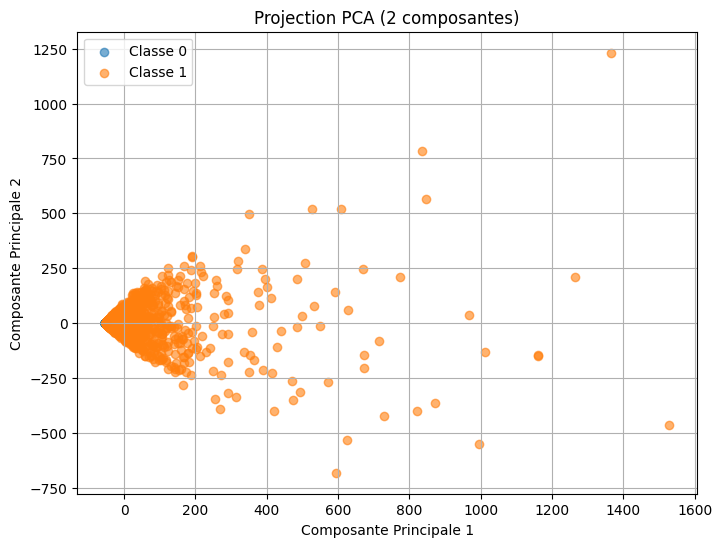

In [ ]:

X_vis = np.array(X_train_pca)
y_vis = np.array(Y_train)

plt.figure(figsize=(8,6))


plt.scatter(
    X_vis[y_vis == 0, 0],
    X_vis[y_vis == 0, 1],
    alpha=0.6,
    label="Classe 0"
)


plt.scatter(
    X_vis[y_vis == 1, 0],
    X_vis[y_vis == 1, 1],
    alpha=0.6,
    label="Classe 1"
)

plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.title("Projection PCA (2 composantes)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("F1:", f1_score(Y_test, y_pred))

Accuracy: 0.9964726631393298
F1: 0.9970326409495549


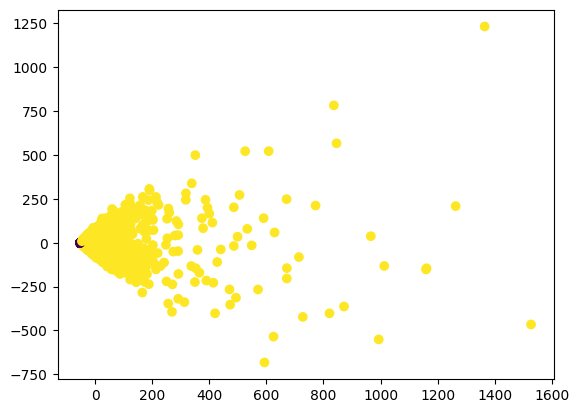

In [ ]:
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=Y_train)